In [1]:
import json
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd

In [2]:
records = []
list_years = list(range(2012, 2025+1))
for year in list_years:
    with open(f"./resources/GFW/GFW_unprocessed/GFW_SWA_AIS_{year}.json") as f:
        raw = json.load(f)

    # Extract the list of vessel records
    entries = raw["entries"][0]["public-global-fishing-effort:v4.0"]
    records.extend(entries)  # Append to the main records list

df1 = pd.DataFrame(records) #convert list of jsons in dataframe

In [3]:
display(df1.head())
df1["flag"].unique()

,callsign,dataset,date,entryTimestamp,exitTimestamp,firstTransmissionDate,flag,geartype,hours,imo,lastTransmissionDate,lat,lon,mmsi,shipName,vesselId,vesselType
0,URBX,public-global-vessel-identity:v4.0,2012-02,2012-01-27T11:00:00Z,2012-10-15T12:00:00Z,2012-01-01T03:00:45Z,UKR,SET_LONGLINES,1.567778,9247912,2026-05-28T03:46:29Z,-54.2,-52.599998,272364000,SIMEIZ,6af768bd5-57a0-668c-2325-4a5698903e84,FISHING
1,LW 3758,public-global-vessel-identity:v4.0,2012-06,2012-04-06T14:00:00Z,2012-11-20T03:00:00Z,2012-01-07T05:20:52Z,ARG,TRAWLERS,14.667222,,2017-03-29T21:03:35Z,-45.4,-63.799999,701000528,ALCOBARI,89bf08659-9b13-aeff-c7cc-8bdcafa7971a,FISHING
2,LW4486,public-global-vessel-identity:v4.0,2012-07,2012-04-09T04:00:00Z,2012-11-07T14:00:00Z,2012-03-12T14:11:30Z,ARG,TRAWLERS,5.120833,9389928,2026-06-13T23:59:54Z,-45.5,-63.099998,701006094,ALVAREZ ENTRENA 2,4562b75ab-b06e-f234-523f-aa2f45cfcf10,FISHING
3,0006047,public-global-vessel-identity:v4.0,2012-10,2012-04-17T16:00:00Z,2012-11-18T06:00:00Z,2012-03-13T15:24:27Z,ARG,TRAWLERS,14.302500,,2015-04-22T16:51:54Z,-45.0,-65.000000,701000882,FELIX AUGUSTO,e71d9a2cc-c23c-7cac-d63e-cdb951987909,FISHING
4,LW 8604,public-global-vessel-identity:v4.0,2012-11,2012-02-25T13:00:00Z,2012-12-30T23:00:00Z,2012-01-17T11:56:54Z,ARG,TRAWLERS,1.562500,7336501,2026-06-13T23:42:16Z,-45.1,-61.400002,701000717,**COALSA SEGUNDO**,7dd844188-8df3-e038-9103-7f78acae2158,FISHING


array(['UKR', 'ARG', 'ESP', 'TWN', 'FLK', 'KOR', 'CHN', 'URY', 'KHM',
       'ARE', 'PRT', 'CHL', 'VUT', 'GBR', 'SLE', 'RUS', '', 'PER', 'NOR',
       'DNK', 'BLZ', 'CYP', 'NZL', 'SHN', 'LTU', 'DEU', 'POL', 'AFG',
       'CUB', 'ALB', 'AUS', 'PAN', 'AND', 'LKA', 'JPN', 'USA', 'FRA',
       'TUV', 'CMR', 'REU', 'NLD', 'NAM', 'ITA', 'ECU', 'EST'],
      dtype=object)

In [4]:

df1["date"] = pd.to_datetime(df1["date"]) # Convert the str time to datetime
df1 = df1[["date", "lat", "lon", "hours", "flag", "geartype"]] # Select only the necessary columns
df1 = df1[df1["flag"].isin(["ESP", "CHN", "KOR", "FLK", "TWN"])]

df1 = df1.replace(r"^\s*$", np.nan, regex=True) # Replace empty strings " " with NaN
df1 = df1.dropna(subset=["lat", "lon", "date", "flag", "geartype"]) # Drop rows with NAN in, for the xarray coordinates 
geartypes_of_interest = ["TRAWLERS", 'SQUID_JIGGER']
df1 = df1[df1['geartype'].isin(geartypes_of_interest)] #We select only the interesting gears for SWA intl

In [5]:
available_polygon = gpd.read_file("./data/available_SWA_fishing_area.geojson") 

gdf1_points = gpd.GeoDataFrame(
    df1,
    geometry=gpd.points_from_xy(df1["lon"], df1["lat"]),  # lon = X, lat = Y
    crs="EPSG:4326"
) #we convert the GFW pandas dataframe to a geopandas dataframe so we can filter for the polygon 

gdf1_filtered = gpd.sjoin(
    gdf1_points,
    available_polygon,
    predicate="intersects",  
    how="inner"
)  #we filter for the available fishing area for the international fleet

In [6]:
gdf1_filtered

,date,lat,lon,hours,flag,geartype,geometry,index_right
5,2012-05-01,-50.4,-61.500000,40.974167,ESP,TRAWLERS,POINT (-61.5 -50.4),0
6,2012-03-01,-51.0,-58.799999,6.883056,TWN,SQUID_JIGGER,POINT (-58.8 -51),0
8,2012-03-01,-51.1,-57.099998,17.547778,FLK,TRAWLERS,POINT (-57.1 -51.1),0
9,2012-05-01,-50.4,-61.299999,6.664444,ESP,TRAWLERS,POINT (-61.3 -50.4),0
10,2012-03-01,-51.0,-58.000000,0.076389,TWN,SQUID_JIGGER,POINT (-58 -51),0
...,...,...,...,...,...,...,...,...
2420653,2025-05-01,-50.5,-61.500000,1.183056,FLK,TRAWLERS,POINT (-61.5 -50.5),0
2420654,2025-12-01,-45.2,-60.400002,16.998056,CHN,SQUID_JIGGER,POINT (-60.4 -45.2),0
2420655,2025-04-01,-51.1,-63.200001,1.109167,TWN,SQUID_JIGGER,POINT (-63.2 -51.1),0
2420656,2025-02-01,-46.4,-60.900002,2.854444,FLK,TRAWLERS,POINT (-60.9 -46.4),0


In [7]:
df = gdf1_filtered.drop(columns=["geometry", "index_right"]).copy() #delete columns from the geopandas dataframe
df_agg = (
    df.groupby(["date", "lat", "lon", "flag", "geartype"], as_index=False)
      .agg(hours=('hours', 'sum'))
) #sum the hours to have data for each flag and geartype rather than for each vessel

df_agg["lat"] = df_agg["lat"].round(1)
df_agg["lon"] = df_agg["lon"].round(1)

In [8]:
dsxr = (
    df_agg
    .set_index(["date", "lat", "lon", "flag", "geartype"]) #we define the xarray coordinates
    .to_xarray()
    .rename({"date": "time"})
) #we convert the pandas dataframe to 

# Define chunk sizes for dask, time in 12-month chunks, lat and lon full size, geartype and flag one at a chunk. 
chunks = {"time": 12, "lat": -1, "lon": -1, "geartype":1, "flag":1}
dsxr = dsxr.chunk(chunks)

In [9]:
dsxr

<xarray.Dataset> Size: 257MB
Dimensions:   (time: 168, lat: 162, lon: 118, flag: 5, geartype: 2)
Coordinates:
  * time      (time) datetime64[ns] 1kB 2012-01-01 2012-02-01 ... 2025-12-01
  * lat       (lat) float64 1kB -56.9 -56.5 -56.3 -56.2 ... -40.2 -40.1 -40.0
  * lon       (lon) float64 944B -63.7 -63.6 -63.5 -63.4 ... -52.2 -52.1 -52.0
  * flag      (flag) object 40B 'CHN' 'ESP' 'FLK' 'KOR' 'TWN'
  * geartype  (geartype) object 16B 'SQUID_JIGGER' 'TRAWLERS'
Data variables:
    hours     (time, lat, lon, flag, geartype) float64 257MB dask.array<chunksize=(12, 162, 118, 1, 1), meta=np.ndarray>

In [10]:
with open("./data/bbox.json", "r") as f:
    bbox = json.load(f)
min_lon, min_lat, max_lon, max_lat = [
        bbox["min_lon"],
        bbox["min_lat"],
        bbox["max_lon"],
        bbox["max_lat"]
    ]
bbox_SWA = [min_lon, min_lat, max_lon, max_lat]


lat_min_xr = dsxr.lat.min().item()
lat_max_xr = dsxr.lat.max().item()
lon_min_xr = dsxr.lon.min().item()
lon_max_xr = dsxr.lon.max().item()
bbox_xr = [lon_min_xr, lat_min_xr, lon_max_xr, lat_max_xr] #bbox from GFW xarray



print("Bounding box from xarray dataset:", bbox_xr)
print("SW Atlantic bounding box:", bbox_SWA) #Southwest Atlantic bounding box is greater, we need to expand mantaining a 0.1 degree resolution

lat_diff = np.diff(dsxr.lat)
lon_diff = np.diff(dsxr.lon)

print("Latitude spacing unique values:", np.unique(lat_diff)) #la resolucion es 0.1 grados (todos los espacios entre datos son multiplos de 0.1)
print("Longitude spacing unique values:", np.unique(lon_diff))

Bounding box from xarray dataset: [-63.7, -56.9, -52.0, -40.0]
SW Atlantic bounding box: [-66.0, -57.0, -52.0, -40.0]
Latitude spacing unique values: [0.1 0.1 0.2 0.4 0.4]
Longitude spacing unique values: [0.1 0.1]


In [11]:
#aumentamos el area rellenando con NaN y ajustamos al target grid para obtener el area del bbox del estudio

target_lons = np.arange(bbox_SWA[0], bbox_SWA[2] + 0.1, 0.1)
target_lats = np.arange(bbox_SWA[1], bbox_SWA[3] + 0.1, 0.1)

dsxr_expanded = dsxr.reindex(
    lat=target_lats,
    lon=target_lons,
    method="nearest",      # We put the closest value in the expanded grid
    tolerance=0.05         # Only if it's within 0.05 degrees, then it's nan
)

dsxr_expanded = dsxr_expanded.chunk({
    "time": 12, # 12 months at a chunk
    "lat": -1, # full size
    "lon": -1,
    "flag": 1, # one at a chunk
    "geartype": 1
}) #we chunk it (for saving the zarr)


In [12]:
#Adding metadata and description to this zarr dataset
dsxr_expanded.attrs['title'] = "SW Atlantic GFW AIS Fishing Effort Data (2012-2024)"
dsxr_expanded.attrs["description"] = (
    """Monthly fishing hours per grid cell in the SW Atlantic, 
    aligned to 0.1° lat/lon grid
    only data from trawlers and squid jiggers vessels included,
    only data within the available fishing area is included which comprises
    international waters and claimed Falkland Islands EEZ."""
)

dsxr_expanded.attrs["source"] = "AIS-based fishing effort dataset"
dsxr_expanded.attrs["created_by"] = "Ruben Barriuso"
dsxr_expanded.attrs["resolution"] = "0.1x0.1 degree"
dsxr_expanded.attrs["date_created"] = "2025-12-29"
dsxr_expanded.attrs["source"] = "Global Fishing Watch (GFW)"

dsxr_expanded["hours"].attrs["long_name"] = "Fishing effort in AIS hours"
dsxr_expanded["hours"].attrs["description"] = (
    "Total monthly fishing effort observed in each grid cell from GFW"
)

In [13]:
#we save the .zarr
dsxr_expanded.to_zarr("./resources/GFW/GFW_AIS_Intl-FK_Trwl-Jgr_2012-2025.zarr", 
                      mode='w',
                      consolidated=True #creates a metadata file for faster access
                      ) 

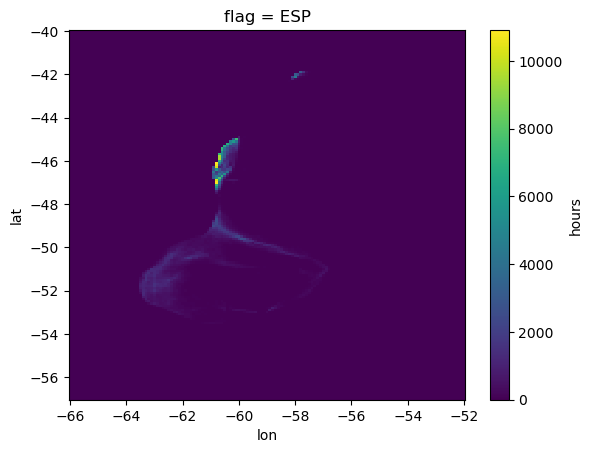

In [14]:
dsxr_expanded.hours.sel(flag="ESP").sum(dim=["geartype", "time"]).compute().plot() #we plot the sum over gear and time for the spanish flag vessels. 